In [1]:
import pandas as pd

df_factor = pd.read_parquet("final_feature_matrix_polished2.parquet")
df_factor

,TradingDate,Symbol,is_hs300,factor_mom_2d,factor_mom_5d,factor_mom_10d,factor_mom_20d,factor_reversal_5d,factor_pos_10d,factor_pos_20d,...,factor_turnover_chg,factor_illiquidity,factor_br,factor_avg_px_bias,factor_up_vol_ratio,factor_daily_pos,factor_pvt_20d,factor_turnover_bias,factor_pv_divergence,target_log_ret
0,2010-02-03,000001,True,-0.419412,0.613713,0.627402,0.541997,-0.613713,-0.236243,0.939585,...,0.167893,-0.591555,0.319372,-2.734753,-0.452381,-0.795573,0.477897,-0.238663,0.0,-0.016972
1,2010-02-03,000002,True,0.120885,0.268189,0.435331,-0.229261,-0.268189,-0.007128,-0.321460,...,-0.451399,-0.548991,-0.548896,-0.467890,-1.799874,-0.564989,-1.929665,-0.263356,0.0,-0.004242
2,2010-02-03,000009,True,-0.476138,0.544517,-0.632029,0.934315,-0.544517,-0.551340,-0.479064,...,-0.182673,-0.678319,1.264516,0.034123,1.131501,-0.054876,2.464601,-0.984421,0.0,0.095745
3,2010-02-03,000012,True,-1.256229,-1.338249,-1.340817,-0.825749,1.338249,-1.678090,-1.466028,...,0.443794,-0.025056,0.123518,-1.273525,-0.079102,0.248499,-0.857317,-0.397479,0.0,-0.003327
4,2010-02-03,000021,True,-0.355677,0.674963,0.227034,0.355731,-0.674963,-0.187312,-0.187903,...,-0.550184,0.844361,0.585947,-0.304910,0.440726,-0.199462,-0.528501,0.073503,0.0,0.009686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2334364,2024-12-30,688472,False,-0.053164,-0.020868,-0.579479,-0.265367,0.020868,-0.719673,-0.315587,...,-0.883087,-0.893420,0.897657,2.342325,-1.255127,0.252305,-1.113922,-2.094955,0.0,0.030727
2334365,2024-12-30,688506,False,2.798698,0.225661,0.466909,-0.980781,-0.225661,0.860256,-0.013906,...,1.671173,1.730541,0.825895,2.890364,-0.182732,1.066892,0.074647,0.811098,0.0,-0.005098
2334366,2024-12-30,688561,False,-0.840162,-0.387732,0.081418,-0.498613,0.387732,-0.277653,-0.325313,...,0.126780,0.968039,-0.297715,1.837282,-0.080424,-0.924835,-0.424770,0.638796,0.0,-0.051927
2334367,2024-12-30,688599,True,-1.202224,-2.026339,-1.993219,-0.849288,2.026339,-1.182325,-0.719093,...,0.940073,1.582597,-0.771212,2.222776,0.306306,-1.351603,0.245011,2.128963,0.0,-0.036625


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from tqdm import tqdm

# --- 1. 环境对齐配置 ---
# 确保时间范围与测试集一致
start_date = pd.to_datetime('2013-07-01')
end_date = pd.to_datetime('2024-12-30')

# 提取特征和目标
target_col = 'target_log_ret' # 假设这已经是月频累计收益率
factor_cols = [col for col in df_factor.columns if col.startswith('factor_')]

# 核心：筛选 HS300 样本，并增加“月份”标记
df_unified = df_factor[
    (df_factor['TradingDate'] >= start_date) & 
    (df_factor['TradingDate'] <= end_date) & 
    (df_factor['is_hs300'] == True)
].copy()

# 关键修改：将日期转换为月频末端日期或月份标签，用于聚合
df_unified['Month'] = df_unified['TradingDate'].dt.to_period('M')

def calculate_monthly_ic(df, factors, target):
    monthly_ic_list = []
    
    # 按月分组计算
    # 在月频回测中，我们通常取每个月最后一天（或月初第一天）的因子快照
    # 这里假设 df_factor 已经是月度重平衡日的截面数据。如果不是，请先进行 .groupby(['Stkcd', 'Month']).last()
    groups = df.groupby('Month')
    
    print(f"🚀 启动月频单因子评估 (样本池: HS300, 周期: {len(groups)} 个月)...")
    
    for month, group in tqdm(groups):
        # 1. 剔除目标值缺失的股票 (对齐机器学习 .dropna())
        # 月频中，target 应该是下个月的收益率
        month_data = group.dropna(subset=[target])
        
        if len(month_data) < 50:
            continue
            
        res = {'Month': month}
        
        for f in factors:
            # 2. 剔除该因子缺失的股票
            valid_data = month_data.dropna(subset=[f])
            
            # 3. 逻辑对齐：因子值不能是常数，且样本足够
            if len(valid_data) > 20 and valid_data[f].nunique() > 1:
                # 统一使用 Rank IC (Spearman)
                # 计算当前月因子值与对应的目标收益率的相关性
                ic, _ = spearmanr(valid_data[f], valid_data[target])
                res[f] = ic
            else:
                res[f] = np.nan
        monthly_ic_list.append(res)
    
    # 转为 DataFrame
    df_monthly_ic = pd.DataFrame(monthly_ic_list).set_index('Month')
    
    # 4. 计算全样本均值（即 Mean IC）
    # 注意：这里计算的是算术平均，即论文中常说的 Mean IC
    summary = pd.DataFrame({
        'Mean_IC': df_monthly_ic.mean(),
        'IC_Std': df_monthly_ic.std(),
        'ICIR': df_monthly_ic.mean() / df_monthly_ic.std()
    }).sort_values('Mean_IC', ascending=False)
    
    return summary, df_monthly_ic

# 执行月频计算
ic_summary_monthly, df_monthly_ic_values = calculate_monthly_ic(df_unified, factor_cols, target_col)

# --- 2. 输出结果 ---
print(f"\n" + "="*45)
print(f"📊 统一口径月频单因子 IC 汇总 (HS300)")
print(f"统计周期: {df_monthly_ic_values.index[0]} 至 {df_monthly_ic_values.index[-1]}")
print("="*45)
print(ic_summary_monthly.head(10))

🚀 启动月频单因子评估 (样本池: HS300, 周期: 138 个月)...


100%|██████████| 138/138 [00:44<00:00,  3.12it/s]


📊 统一口径月频单因子 IC 汇总 (HS300)
统计周期: 2013-07 至 2024-12
                        Mean_IC    IC_Std      ICIR
factor_reversal_5d     0.013590  0.022372  0.607459
factor_ep_diff_20      0.012317  0.020582  0.598434
factor_bp              0.011047  0.021982  0.502552
factor_ep              0.008871  0.020436  0.434083
factor_aroon_up        0.007134  0.024442  0.291867
factor_cfp             0.006264  0.013365  0.468712
factor_fcf_yield       0.006025  0.013561  0.444283
factor_sp              0.005670  0.019311  0.293609
factor_revenue_to_mkt  0.005670  0.019311  0.293609
factor_size_ln         0.005056  0.023435  0.215735


✅ 已生成最强因子 factor_reversal_5d 的月度深度分析图：top_monthly_factor_analysis.png


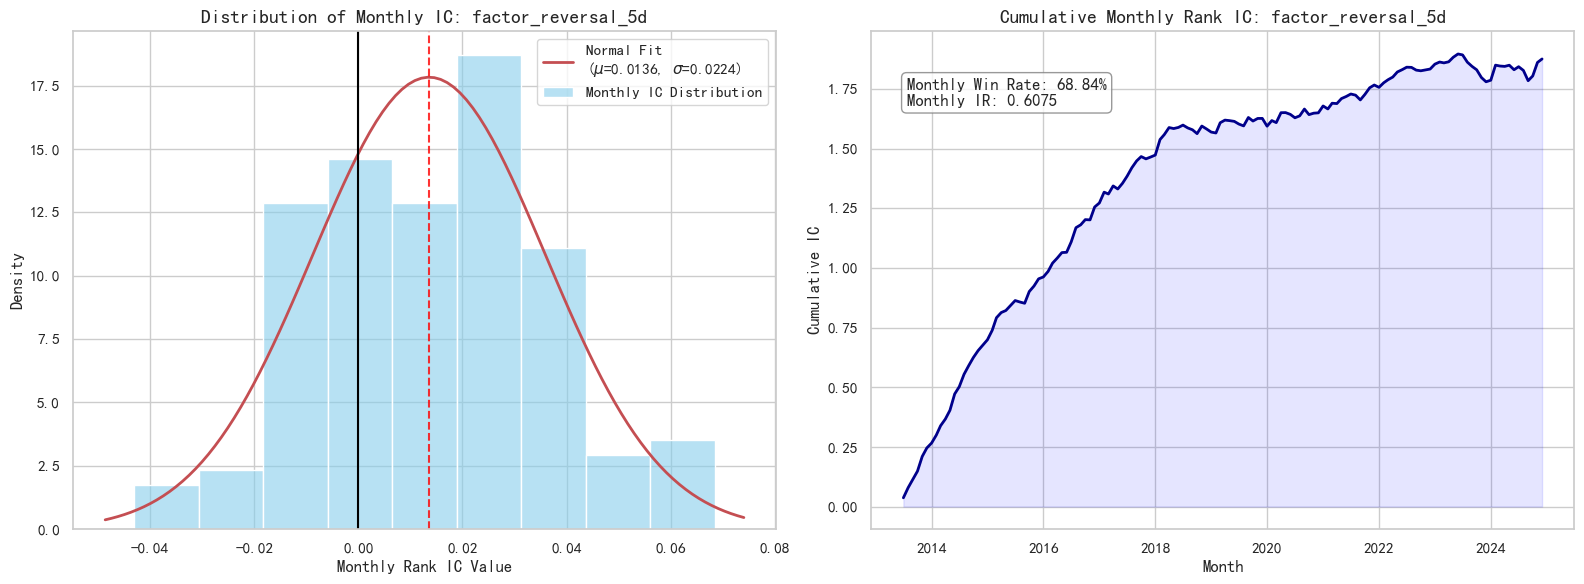

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# 设置绘图风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False 

def plot_top_factor_analysis_monthly(df_monthly_ic, ic_summary):
    """
    针对月频 IC 数据的深度分析绘图
    """
    # 1. 获取最强因子名称 (基于之前计算的 ic_summary_monthly)
    top_factor = ic_summary.index[0]
    # 确保索引为时间格式，方便累计曲线绘图
    top_factor_series = df_monthly_ic[top_factor].dropna()
    
    # 创建画布 (一行两列)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 图 A: Monthly IC 分布直方图 + 正态分布拟合 ---
    sns.histplot(top_factor_series, kde=False, stat="density", ax=axes[0], color='skyblue', alpha=0.6, label='Monthly IC Distribution')
    
    # 拟合正态分布曲线
    mu, std = top_factor_series.mean(), top_factor_series.std()
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    axes[0].plot(x, p, 'r', linewidth=2, label=f'Normal Fit\n($\mu$={mu:.4f}, $\sigma$={std:.4f})')
    
    # 添加统计标注
    axes[0].axvline(mu, color='red', linestyle='--', alpha=0.8)
    axes[0].axvline(0, color='black', linewidth=1.5)
    axes[0].set_title(f'Distribution of Monthly IC: {top_factor}', fontsize=14)
    axes[0].set_xlabel('Monthly Rank IC Value')
    axes[0].legend()

    # --- 图 B: 累计 IC 曲线 (月度稳定性分析) ---
    # 将 PeriodIndex 转回 Datetime 对象以便绘图清晰
    plot_idx = top_factor_series.index.to_timestamp()
    cum_ic = top_factor_series.cumsum()
    
    axes[1].plot(plot_idx, cum_ic.values, color='darkblue', linewidth=2)
    axes[1].fill_between(plot_idx, 0, cum_ic.values, color='blue', alpha=0.1)
    axes[1].set_title(f'Cumulative Monthly Rank IC: {top_factor}', fontsize=14)
    axes[1].set_ylabel('Cumulative IC')
    axes[1].set_xlabel('Month')
    
    # 计算胜率 (月度 IC > 0 的比例)
    win_rate = (top_factor_series > 0).mean()
    axes[1].annotate(f'Monthly Win Rate: {win_rate:.2%}\nMonthly IR: {mu/std:.4f}', 
                     xy=(0.05, 0.85), xycoords='axes fraction', 
                     bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

    plt.tight_layout()
    plt.savefig('top_monthly_factor_analysis.png', dpi=300)
    print(f"✅ 已生成最强因子 {top_factor} 的月度深度分析图：top_monthly_factor_analysis.png")

# 执行绘图 (使用月频计算结果)
plot_top_factor_analysis_monthly(df_monthly_ic_values, ic_summary_monthly)

🚀 启动月频最强因子衰减分析: factor_reversal_5d
📊 正在计算 M+1 到 M+6 的预测力衰减...


C:\Users\HP\AppData\Local\Temp\ipykernel_73548\172086414.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_ics = month_groups.apply(get_monthly_rank_ic)


   - M+1 计算完成, Mean IC: 0.0136


C:\Users\HP\AppData\Local\Temp\ipykernel_73548\172086414.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_ics = month_groups.apply(get_monthly_rank_ic)


   - M+2 计算完成, Mean IC: 0.0100


...

   - M+4 计算完成, Mean IC: 0.0060


C:\Users\HP\AppData\Local\Temp\ipykernel_73548\172086414.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_ics = month_groups.apply(get_monthly_rank_ic)


   - M+5 计算完成, Mean IC: 0.0029


C:\Users\HP\AppData\Local\Temp\ipykernel_73548\172086414.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_ics = month_groups.apply(get_monthly_rank_ic)


   - M+6 计算完成, Mean IC: 0.0027


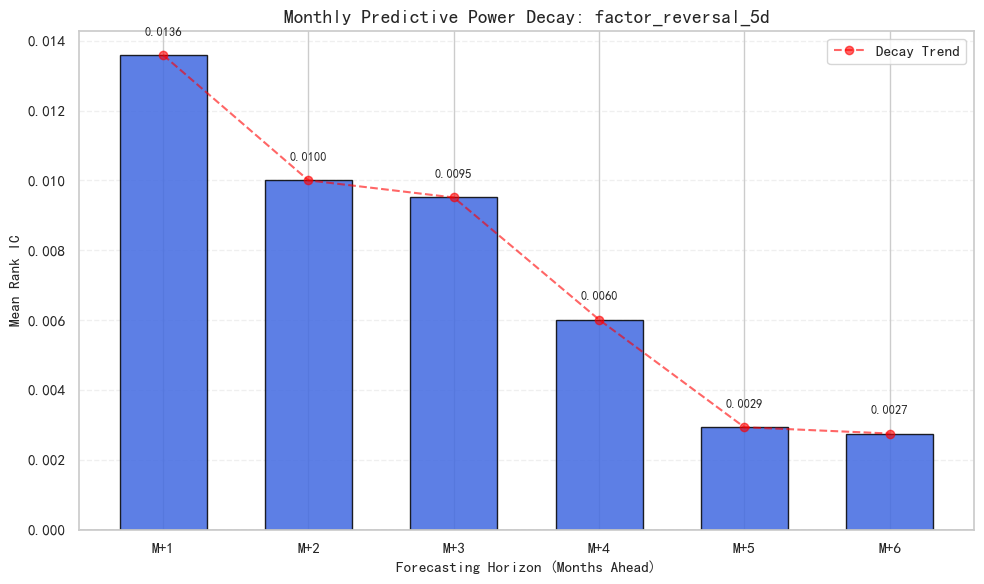

✅ 绘图成功！文件已保存为 top_monthly_factor_decay.png


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from tqdm import tqdm

def plot_top_factor_decay_monthly(df, factors, target_col, stock_id_col='Symbol', max_lag=6):
    """
    针对月频数据的因子预测力衰减分析 (T+1 到 T+N 月)
    """
    # 1. 获取排名第一的因子名称
    top_factor = factors[0]
    print(f"🚀 启动月频最强因子衰减分析: {top_factor}")
    print(f"📊 正在计算 M+1 到 M+{max_lag} 的预测力衰减...")
    
    # 2. 准备数据并转换为月频索引
    required_cols = ['TradingDate', stock_id_col, target_col, top_factor]
    working_df = df[required_cols].copy()
    working_df['TradingDate'] = pd.to_datetime(working_df['TradingDate'])
    
    # 核心：确保时间是对齐到月份的 Period
    working_df['Month'] = working_df['TradingDate'].dt.to_period('M')
    working_df = working_df.sort_values([stock_id_col, 'Month'])
    
    # 3. 构造未来多月收益率 (Forward Monthly Returns)
    # 在月频数据中，shift(-1) 代表下个月的收益
    for lag in range(1, max_lag + 1):
        target_name = f'target_M{lag}'
        # 按股票代码分组，获取未来第 lag 期的收益
        # 假设原始 target_log_ret 是从 t 到 t+1 月的收益
        working_df[target_name] = working_df.groupby(stock_id_col)[target_col].shift(-(lag-1))
    
    # 4. 计算每月 IC 的均值
    lags_ic = []
    month_groups = working_df.groupby('Month')
    
    for lag in range(1, max_lag + 1):
        target_name = f'target_M{lag}'
        
        def get_monthly_rank_ic(group):
            valid = group[[top_factor, target_name]].dropna()
            # 逻辑对齐：确保样本量足够且因子值非单一常数
            if len(valid) > 30 and valid[top_factor].nunique() > 1:
                return spearmanr(valid[top_factor], valid[target_name])[0]
            return np.nan

        # 计算该 Lag 下所有月份的 IC
        monthly_ics = month_groups.apply(get_monthly_rank_ic)
        lags_ic.append(monthly_ics.mean())
        print(f"   - M+{lag} 计算完成, Mean IC: {lags_ic[-1]:.4f}")

    # 5. 绘图美化
    plt.figure(figsize=(10, 6))
    x_labels = [f'M+{i}' for i in range(1, max_lag + 1)]
    
    # 绘制单因子柱状图
    bars = plt.bar(x_labels, lags_ic, color='royalblue', alpha=0.85, edgecolor='black', width=0.6)
    
    # 在柱子上标注数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (0.0005 if height > 0 else -0.002),
                 f'{height:.4f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

    plt.title(f"Monthly Predictive Power Decay: {top_factor}", fontsize=14, fontweight='bold')
    plt.xlabel("Forecasting Horizon (Months Ahead)", fontsize=11)
    plt.ylabel("Mean Rank IC", fontsize=11)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # 增加衰减趋势线
    plt.plot(x_labels, lags_ic, marker='o', color='red', linestyle='--', alpha=0.6, label='Decay Trend')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('top_monthly_factor_decay.png', dpi=300)
    plt.show()
    print(f"✅ 绘图成功！文件已保存为 top_monthly_factor_decay.png")

# --- 执行 ---
# 使用之前月频计算得到的排序结果 ic_summary_monthly
plot_top_factor_decay_monthly(
    df_unified, 
    ic_summary_monthly.index.tolist(), 
    'target_log_ret', 
    stock_id_col='Symbol', # 根据你的数据集字段名修改，如 'Symbol' 或 'Stkcd'
    max_lag=6 # 月频分析通常看半年（6个月）的衰减
)